# TP 14 - Premiers problèmes gloutons

## Exercice 1 : Rendu de monnaie

On dispose de l'ensemble des pièces et billets suivant (on retire volontairement les centimes) : 
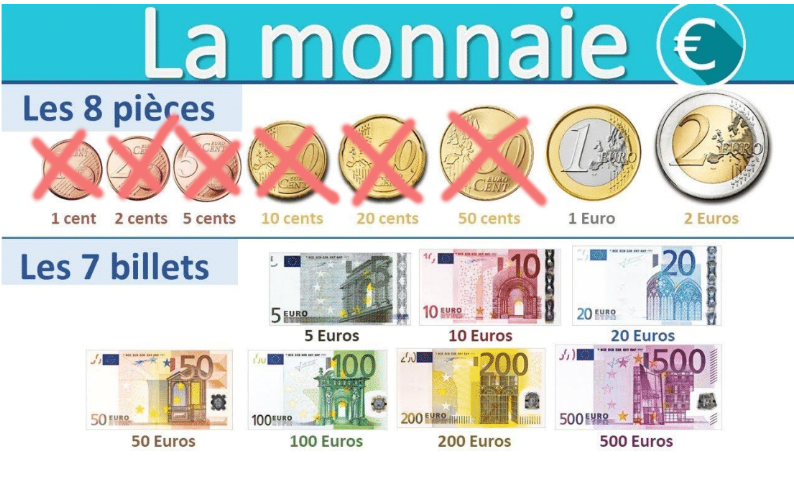

!!! info 
On souhaite rendre la monnaie avec le moins de pièces/billets possible.
Le principe de l’algorithme glouton dans le cas du rendu de monnaie consiste à rendre la monnaie en
tentant de rendre à chaque fois, le plus grand billet ou la plus grande pièce possible, puis de répéter
l’opération jusqu’à ce qu’il ne reste plus rien.

On stock dans une variable global la valeur des pièces et billets dans l'ordre décroissant.
!!!

!!! question Question 1
Définissez une variable qui contient une liste des valeurs des pièces et billets à notre disposition.
!!!

In [4]:
monnaie = [500, 200, 100, 50, 20, 10, 5, 2, 1]

!!! question Question 2
Écrire une fonction `piece_billet_max_1(reste)` qui prend une valeur de rendu de monnaie à rendre et renvoie la valeur de la pièce ou du billet maximum que l'on peut rendre. 

**V1 : Avec une boucle while (sans for).**
!!!

In [5]:
# avec une boucle while
def piece_billet_max_1(reste):
    i = 0
    while i < len(monnaie) and reste < monnaie[i]:
        i+= 1
    return monnaie[i]

In [6]:
print(piece_billet_max_1(102)) #100
print(piece_billet_max_1(750)) #500
print(piece_billet_max_1(2)) #2

100
500
2


!!! question Question 3
Écrire une fonction `piece_billet_max_2(reste)` qui prend une valeur de rendu de monnaie à rendre et renvoie la valeur de la pièce ou du billet maximum que l'on peut rendre. 

**V2 : Avec une boucle for (sans while).**
!!!

In [7]:
#avec une boucle for
def piece_billet_max_2(reste):
    for e in monnaie:
        if e <= reste:
            return e

In [8]:
print(piece_billet_max_2(102)) #100
print(piece_billet_max_2(750)) #500
print(piece_billet_max_2(2)) #2

100
500
2


!!! question Question 4
Écrire une fonction `rendu_monnaie_rec(somme : int) -> list[int]` qui renvoie une liste de pieces et billets à rendre pour rendre la somme en utilisant l'algorithme glouton qui prend le plus grand billet possible à chaque fois.

**V1 : De façon itérative (avec for et/ou while)**
!!!

In [9]:
def rendu_monnaie(somme):
    rendu = []
    while somme > 0 :
        prochain = piece_billet_max_1(somme)
        rendu.append(prochain)
        somme -= prochain
    return rendu

In [10]:
print(rendu_monnaie(123)) #[100, 20, 2, 1]

[100, 20, 2, 1]


!!! question Question 5
Écrire une fonction `rendu_monnaie_rec(somme : int) -> list[int]` qui renvoie une liste de pieces et billets à rendre pour rendre la somme en utilisant l'algorithme glouton qui prend le plus grand billet possible à chaque fois.

**V2 : De façon récursive**
!!!

In [19]:
def rendu_monnaie_rec(somme):
    if somme == 0 :
        return []

    prochain = piece_billet_max_1(somme)
    return [prochain] + rendu_monnaie_rec(somme - prochain)


In [20]:
print(rendu_monnaie_rec(123)) #[100, 20, 2, 1]

[100, 20, 2, 1]


In [21]:
# autre version avec la liste en paramètre avec fonction auxilière
def rendu_monnaie_rec_aux(somme, l):
    if somme == 0 :
        return l

    prochain = piece_billet_max_1(somme)
    l.append(prochain)
    return rendu_monnaie_rec_aux(somme - prochain, l)

def rendu_monnaie_rec(somme):
    return rendu_monnaie_rec_aux(somme, [])

In [22]:
print(rendu_monnaie_rec(123)) #[100, 20, 2, 1]

[100, 20, 2, 1]


!!! question Question 6
Pour la monnaie que l'on a choisi, est-ce que cette algorithme glouton est optimal (il renvoie la solution contenant le moins de billets/pièces possible)  ?
!!!

!!! question Question 7
Cet algorithme n'est pas optimal pour toutes les monnaies. Trouver un ensemble de valeurs de pièces/billets associé à une somme à rendre qui ne renvoie pas un résultat optimal.
!!!

In [23]:
monnaie = [5, 4, 1]
def piece_billet_max_1(reste):
    i = 0
    while i < len(monnaie) and reste < monnaie[i]:
        i+= 1
    return monnaie[i]

def rendu_monnaie(somme):
    rendu = []
    while somme > 0 :
        prochain = piece_billet_max_1(somme)
        rendu.append(prochain)
        somme -= prochain
    return rendu

print(rendu_monnaie(8))

[5, 1, 1, 1]


Avec la monnaie `[5, 4, 1]` et la somme `8` à rendre, avec cet algorithme on renverrait : `[5,1,1,1]` au lieu de `[4,4]`.

## Exercice 2 - Problème du sac à dos

!!! info
On dispose d’un sac à dos de capacité maximale `capacite`.
On a $n$ objets, l’objet $i$ ayant :
- un poids $p_i > 0$ 
- une valeur $v_i > 0$

Le but est de choisir un sous-ensemble d’objets tel que la somme des poids ne dépasse pas `capacite` et que la valeur totale soit maximale.
!!!
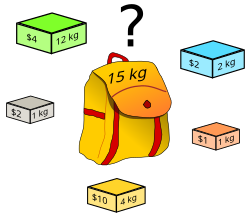


!!! example Modélisation
On modélise les objets que l'on peut mettre dans le sac part une liste de tuple `(poids, valeur)`
!!!

!!! question Question 1
Proposer **3** stratégies gloutonne qu'on pourrait mettre en place pour remplir le sac. Je ne demande pas de la coder mais de proposer des idées.
!!!

!!! question Question 2
Pour chacune des stratégies gloutonnes énoncées, dire si vous pensez qu'elle est optimale. Dans le cas contraire donner un contre exemple.
!!!

!!! question Question 3
Implementer la fonction gloutonne qui vous semble la meilleure des 3 proposées précédemment. \
Cette fonction devra renvoyer la valeur de votre sac après l'ajout de tous les objets possibles.

_Je ne donne pas plus d'information volontairement. À vous de voire comment modéliser (représenter sous formes informatique) les objets, et comment faire votre fonction. Vous pouvez bien sûr faire plusieurs fonctions intermédiaire si besoin._
!!!

In [24]:
def ratio(objet):
    poids, valeur = objet
    return valeur / poids

def tri_bulles_ratio(objets):
    """
    Trie les objets par ratio valeur/poids décroissant
    avec un tri par bulles.
    """
    objets_tries = objets.copy()
    n = len(objets_tries)

    for i in range(n):
        for j in range(n - 1):
            if ratio(objets_tries[j]) < ratio(objets_tries[j + 1]):
                objets_tries[j], objets_tries[j + 1] = objets_tries[j + 1], objets_tries[j]

    return objets_tries

def sac_a_dos_glouton_ratio(capacite, objets):
    """
    capacite : capacité maximale du sac
    objets : liste de tuples (poids, valeur)
    retourne : (valeur_totale, objets_pris)
    """
    objets_tries = tri_bulles_ratio(objets)
    # ou sinon : objets_tries = sorted(objets, key=ratio, reverse=True)
    
    reste = capacite
    valeur_totale = 0
    solution = []

    for objet in objets_tries:
        poids, valeur = objet
        if poids <= reste:
            solution.append(objet)
            valeur_totale += valeur
            reste -= poids

    return valeur_totale, solution

In [25]:
objets = [
    (10, 60),
    (20, 100),
    (30, 120)
]

capacite = 50

valeur, solution = sac_a_dos_glouton_ratio(capacite, objets)

print("Valeur totale :", valeur)
print("Objets pris :", solution)

Valeur totale : 160
Objets pris : [(10, 60), (20, 100)]
